In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [13]:
investor_transactions = pd.read_csv(r'C:\Users\shub2\OneDrive\Desktop\bluestock_mf_capstone\data/processed/clean_transactions.csv')

scheme_performance = pd.read_csv(r'C:\Users\shub2\OneDrive\Desktop\bluestock_mf_capstone/data/processed/clean_performance.csv')

nav_history = pd.read_csv(r'C:\Users\shub2\OneDrive\Desktop\bluestock_mf_capstone/data/processed/clean_nav.csv')

fund_master = pd.read_csv(r'C:\Users\shub2\OneDrive\Desktop\bluestock_mf_capstone/data/raw/fund_master.csv')

In [14]:
# Fund Category Distribution Analysis
# Q1. Which category has the most schemes?
category_counts = fund_master['category'].value_counts()

category_counts

category
Equity    34
Debt       6
Name: count, dtype: int64

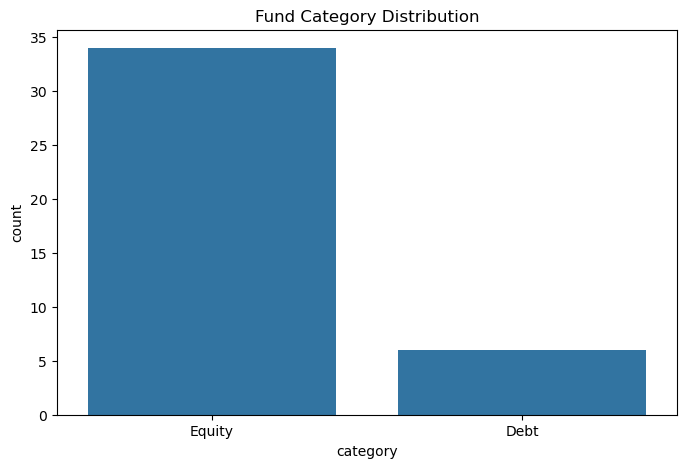

In [15]:
# Visualisation
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x='category'
)

plt.title('Fund Category Distribution')

plt.show()

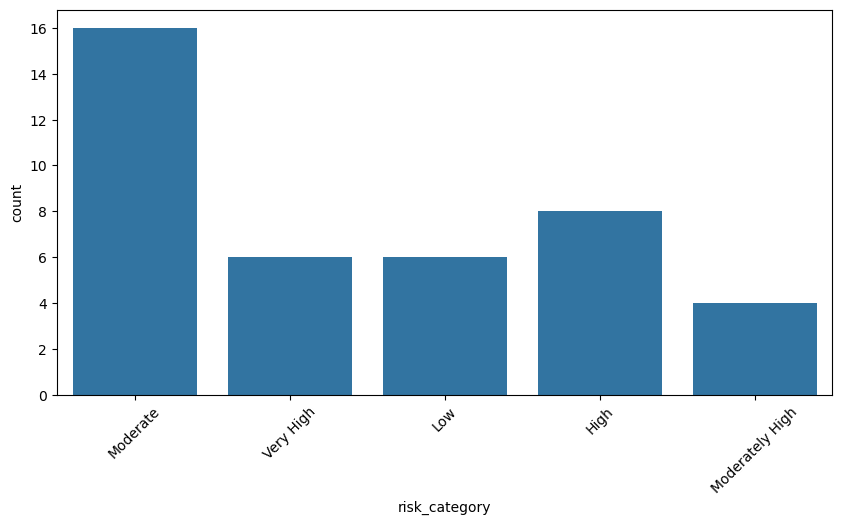

In [16]:
# Risk Category Distribution Analysis
# How risky are the available funds?
plt.figure(figsize=(10,5))

sns.countplot(
    data=fund_master,
    x='risk_category'
)

plt.xticks(rotation=45)

plt.show()

In [18]:
# Top Fund Houses
# Which AMC has most schemes?
top_houses = fund_master[
    'fund_house'
].value_counts().head(10)

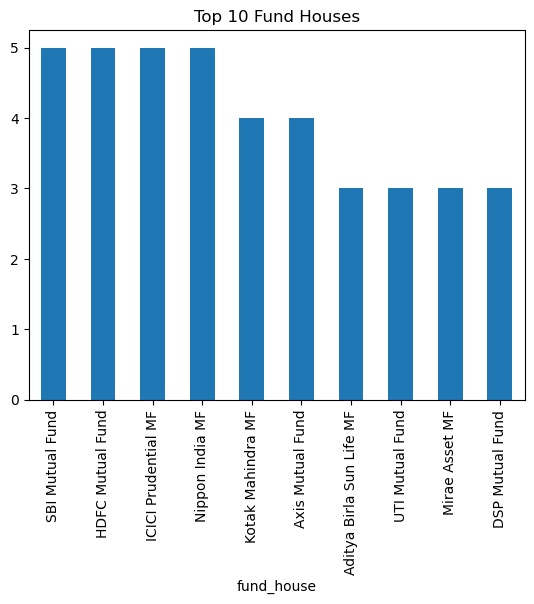

In [19]:
top_houses.plot(
    kind='bar'
)

plt.title(
    'Top 10 Fund Houses'
)

plt.show()

In [21]:
# Transaction Type Distribution
# Which transaction type dominates?
investor_transactions[
    'transaction_type'
].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

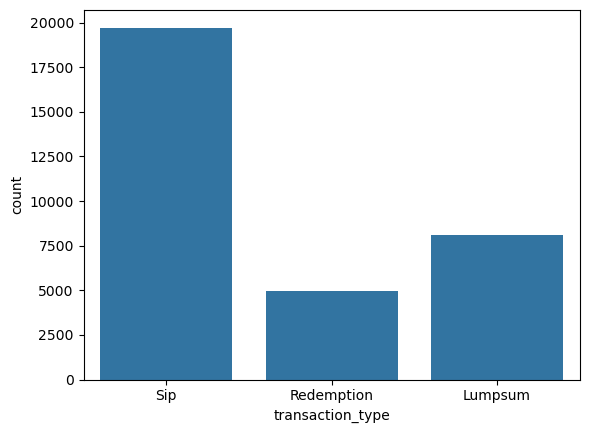

In [23]:
sns.countplot(
    data=investor_transactions,
    x='transaction_type'
)

plt.show()

In [25]:
# State-wise Investment
# Which states invest the most?
state_investment = investor_transactions.groupby(
    'state'
)['amount_inr'].sum()

state_investment = state_investment.sort_values(
    ascending=False
)

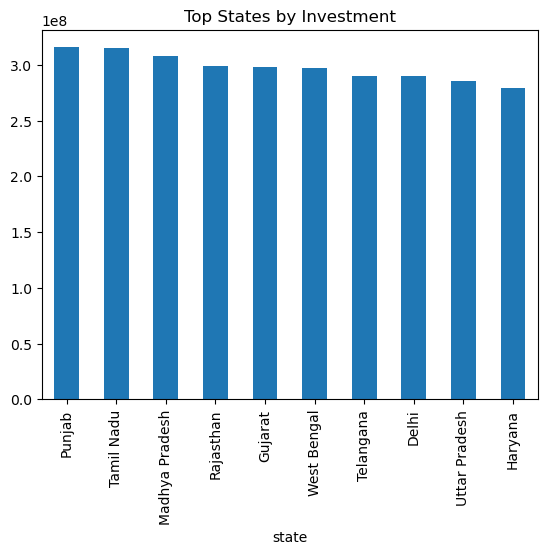

In [26]:
state_investment.head(10).plot(
    kind='bar'
)

plt.title(
    'Top States by Investment'
)

plt.show()

In [28]:
# T30 vs B30 Cities
# Very important AMFI metric.
city_tier = investor_transactions.groupby(
    'city_tier'
)['amount_inr'].sum()

city_tier

city_tier
B30    1202325640
T30    2319254790
Name: amount_inr, dtype: int64

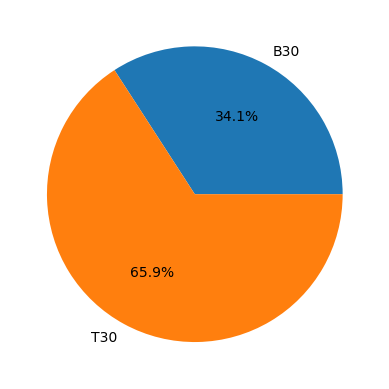

In [29]:
city_tier.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.show()

In [30]:
# Income Group Analysis
# Who invests more?
investor_transactions.groupby(
    'age_group'
)['amount_inr'].mean()

age_group
18-25    108144.709520
26-35    107821.452722
36-45    107003.133808
46-55    107278.769251
56+      105613.105497
Name: amount_inr, dtype: float64

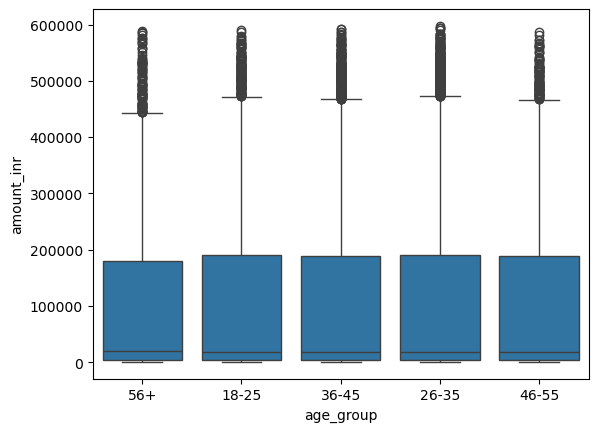

In [32]:
sns.boxplot(
    data=investor_transactions,
    x='age_group',
    y='amount_inr'
)

plt.show()

In [33]:
# Payment Mode Analysis
investor_transactions[
    'payment_mode'
].value_counts()

payment_mode
Net Banking    8250
Cheque         8228
UPI            8154
Mandate        8146
Name: count, dtype: int64

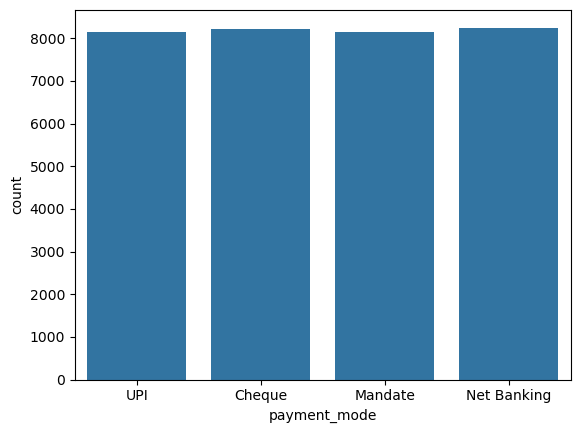

In [34]:
sns.countplot(
    data=investor_transactions,
    x='payment_mode'
)

plt.show()

In [37]:
# Top Performing Funds
top_funds = scheme_performance.sort_values(
    'return_3yr_pct',
    ascending=False
).head(10)

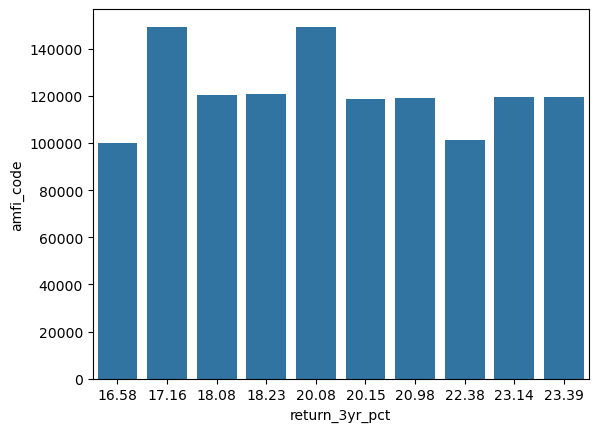

In [38]:
sns.barplot(
    data=top_funds,
    x='return_3yr_pct',
    y='amfi_code'
)

plt.show()

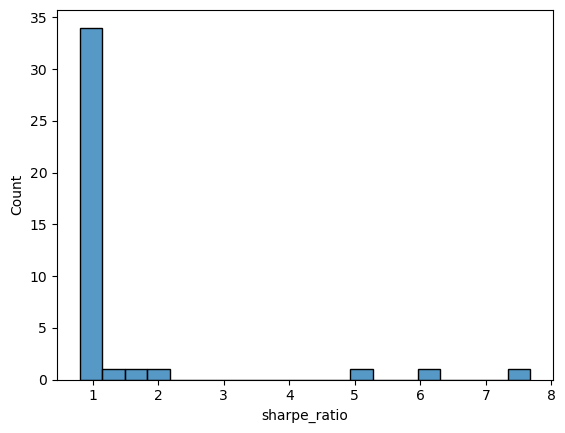

In [39]:
# Sharpe Ratio Analysis
# Risk-adjusted returns.
sns.histplot(
    scheme_performance['sharpe_ratio'],
    bins=20
)

plt.show()

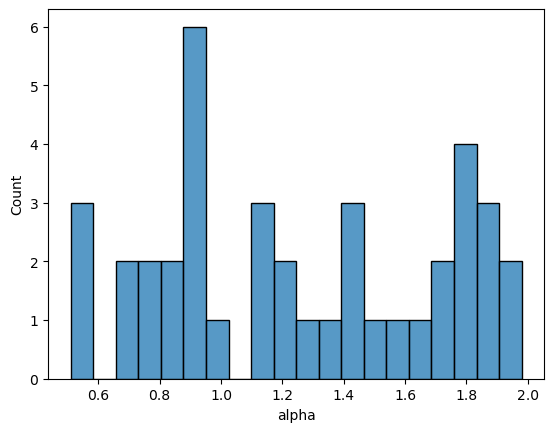

In [47]:
# Alpha Distribution
sns.histplot(
    scheme_performance['alpha'],
    bins=20
)

plt.show()

In [46]:
# Correlation Matrix
# Most important EDA chart.
numeric_cols = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio'
]

corr = corr = scheme_performance[
    numeric_cols
].corr()

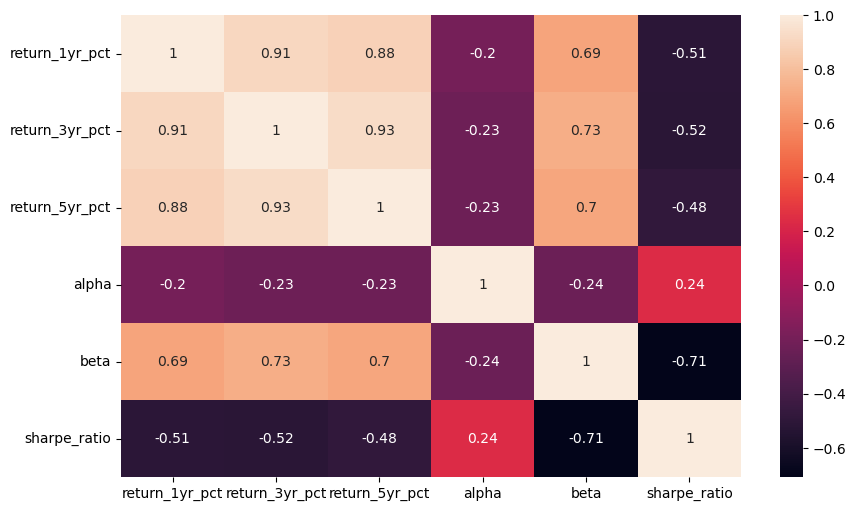

In [48]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True
)

plt.show()

In [50]:
# NAV Trend of a Fund
nav_history['date'] = pd.to_datetime(
    nav_history['date']
)

sample = nav_history[
    nav_history['amfi_code'] == 125497
]

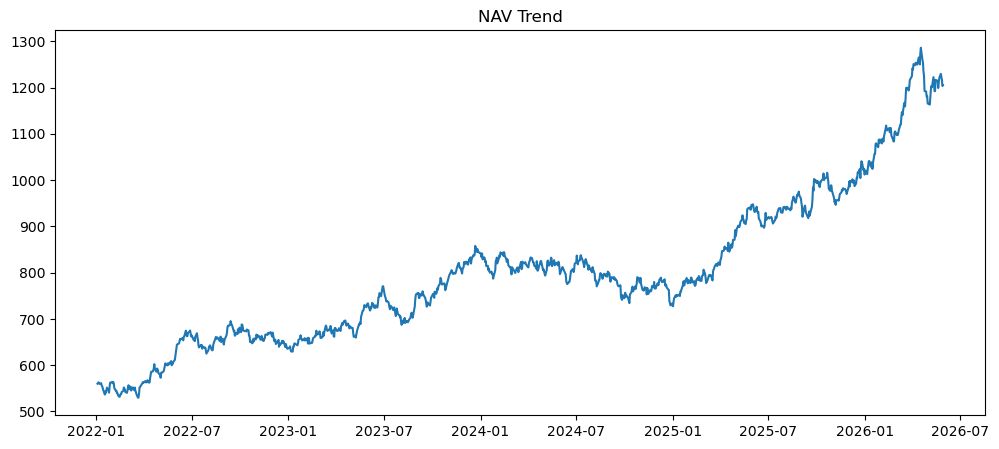

In [51]:
plt.figure(figsize=(12,5))

plt.plot(
    sample['date'],
    sample['nav']
)

plt.title(
    'NAV Trend'
)

plt.show()